In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import numpy as np
import time

%matplotlib inline

In [2]:
def get_total_df(dirpath):
    filenames = [os.path.join(dirpath, filename) for filename in os.listdir(dirpath) if os.path.splitext(os.path.basename(filename))[1] == ".csv" and not "Log" in filename]
    dfs=[]
    for f in filenames:
        df = pd.read_csv(f, header=6, skipfooter=7, engine='python')
        df["Freq(Hz)"] /= 1e9 
        df["Ang(DEG)"] = float(os.path.splitext(os.path.basename(f))[0])
        df = df.rename({"Freq(Hz)":"Freq(GHz)"}, axis="columns")

        dfs.append(df)
    return pd.concat(dfs).reset_index()

def plot_against_freq(cat, key="S21(DB)", **kwargs):
    cmap_ang = plt.get_cmap("bwr")
    colors_ang = cmap_ang(np.linspace(0, 1, len(cat["Ang(DEG)"].unique())))
    cdict_ang = dict(zip(np.sort(cat["Ang(DEG)"].unique()), colors_ang))

    grouped_cat = cat.groupby("Ang(DEG)")
    plt.figure()
    for _ang, ang in enumerate(cat["Ang(DEG)"].unique()):
        subcat = grouped_cat.get_group(ang)
        plt.plot(subcat["Freq(GHz)"], subcat[key], color=cdict_ang[ang], **kwargs)
    plt.ylabel(key)
    plt.xlabel("Frequency (GHz)")
    plt.show()

def plot_against_ang(cat, key="S21(DB)", cmap="plasma", **kwargs):
    cmap_freq = plt.get_cmap(cmap)
    colors_freq = cmap_freq(np.linspace(0, 1, len(cat["Freq(GHz)"].unique())))
    cdict_freq = dict(zip(np.sort(cat["Freq(GHz)"].unique()), colors_freq))
    fig, axs = plt.subplots(1, 2, figsize=(10, 6))
    #cat.sort_values(by="Ang(DEG)", inplace=True)

    # a, b, c = np.polyfit(cat["Ang(DEG)"], (cat["S12(DB)"] - cat["S12(DB)"].max()), deg=2)
    # ang = cat["Ang(DEG)"].unique()
    # fit = ang**2*a + ang*b

    maxs = []

    for freq in cat["Freq(GHz)"].unique():
        subcat = cat[cat["Freq(GHz)"] == freq]
        a, b, c = np.polyfit(subcat["Ang(DEG)"], (subcat[key] - subcat[key].max()), deg=2)
        ang = subcat["Ang(DEG)"].unique()
        fit = ang**2*a + ang*b + c
        maxs.append(-b/(2*a))
        #axs[0].plot(subcat["Ang(DEG)"], (subcat[key] - subcat[key].max()), '-', color=cdict_freq[freq], **kwargs)
        axs[0].plot(ang, fit, '-', color=cdict_freq[freq], **kwargs)

        # axs[1].plot(subcat["Ang(DEG)"], (subcat["S21(DB)"] - subcat["S21(DB)"].max()), '-', color=cdict_freq[freq])
        #axs[1].plot(subcat["Ang(DEG)"], subcat["S12(DEG)"], 'o', color=cdict_freq[freq])

        #axs[0].plot(ang, fit, 'g-', lw=3)
        axs[1].plot(freq, -b/(2*a), 'o', color=cdict_freq[freq])
    axs[0].axvline(np.mean(maxs), color="g", ls="--", label=f"{ang[fit.argmax()]:.2f} deg")
    axs[0].set_ylabel(key)
    axs[0].set_xlabel("Angle (deg)")
    axs[0].legend()
    print(np.mean(maxs))
    plt.show()

In [69]:
iterations = 10
#dirpaths = [f"2025_01_31_scan_no_extension_{num:03d}" for num in range(10,20)]
dirpaths = [f"high_resolution_samples/scan_Eplane/2025_02_04_scan_Eplane_{num:03d}" for num in range(10)]# + [f"high_resolution_samples/scan_Hplane/2025_02_03_scan_Hplane_{num:03d}" for num in range(11,21)] + [f"high_resolution_samples/scan_Hplane/2025_02_05_scan_Hplane_{num:03d}" for num in range(10)] + [f"high_resolution_samples/scan_Hplane/2025_02_05_scan_Hplane_{num:03d}" for num in range(10,20)]
xpol_dirpaths = [f"high_resolution_samples/scan_xpol_Eplane/2025_02_04_crosspol_Eplane_{num:03d}" for num in range(10)]# + [f"high_resolution_samples/scan_xpol_Hplane/2025_02_04_crosspol_Hplane_{num:03d}" for num in range(30,40)]


#dirpaths += xpol_dirpaths

cats = []
for _dirpath, dirpath in enumerate(dirpaths):
    try: 
        cat=get_total_df(dirpath=dirpath)
        cat["run"] = _dirpath
        cat["pol"] = "copolar"
        cats.append(cat)
    except:
        continue

for _dirpath, dirpath in enumerate(xpol_dirpaths):
    try: 
        cat=get_total_df(dirpath=dirpath)
        cat["run"] = _dirpath
        cat["pol"] = "crosspolar"
        cats.append(cat)
    except:
        continue

cat_tot = pd.concat(cats)
cat_tot.sort_values(by=["Ang(DEG)", "Freq(GHz)"], inplace=True)

In [70]:
cat[cat['pol']=='crosspolar']

,index,Freq(GHz),S11(DB),S11(DEG),S12(DB),S12(DEG),S21(DB),S21(DEG),S22(DB),S22(DEG),Ang(DEG),run,pol
0,0,75.0,-17.056604,-3.626138,-85.711304,-38.250938,-98.138718,-39.529392,-49.746986,92.789688,-0.0,9,crosspolar
1,1,75.5,-17.370853,-50.813766,-88.432159,176.189560,-100.163660,122.424750,-48.254990,153.833310,-0.0,9,crosspolar
2,2,76.0,-17.876703,-91.063255,-89.456337,22.980328,-101.625420,11.978940,-49.927418,158.498200,-0.0,9,crosspolar
3,3,76.5,-18.981741,-122.412830,-98.344673,126.595570,-106.285340,109.129540,-50.864510,-137.250260,-0.0,9,crosspolar
4,4,77.0,-18.362547,-158.622990,-89.397995,-113.954630,-100.544400,-102.789790,-49.144039,-89.585472,-0.0,9,crosspolar
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12846,66,108.0,-25.314234,119.445450,-90.742836,-150.287220,-110.714200,4.214132,-56.993443,-77.214645,90.0,9,crosspolar
12847,67,108.5,-24.111591,173.583530,-85.694473,160.474000,-103.916930,38.962109,-53.761185,88.321411,90.0,9,crosspolar
12848,68,109.0,-25.649757,-120.530360,-88.905647,67.893806,-98.328018,-66.295464,-70.507034,26.360661,90.0,9,crosspolar
12849,69,109.5,-23.585676,-55.914307,-90.598633,22.288898,-105.471140,-45.027214,-52.026722,-112.892540,90.0,9,crosspolar


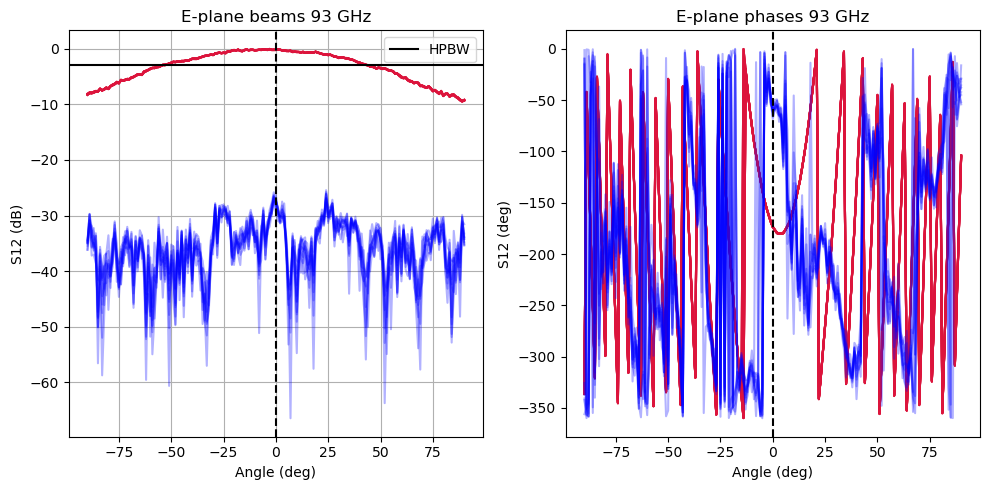

In [73]:
freq = 93

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for cat in cats:

    if (cat["pol"].unique()=="copolar"):
        if cat["run"].unique()<20:
            c="crimson"
        if cat["run"].unique()>20 and cat["run"].unique()<30:
            c='green'
        if cat["run"].unique()>30:
            c = 'orange'
        alpha=1
    else:
        if cat["run"].unique()<10:
            c="blue"
            alpha=0.3
        else:
            c='blue'
        alpha=0.3
    
    #if (cat["run"].unique()<1):
    #    c="crimson"
    #elif (cat["run"].unique()<2):
    #    c="cornflowerblue"
    #elif (cat["run"].unique()==3):
    #    c="k"
    #elif (cat["run"].unique()<31):
    #    c="green"

    subcat = cat[cat["Freq(GHz)"] == freq]
    subcat = subcat.sort_values("Ang(DEG)")
    ang = subcat["Ang(DEG)"]
    #ang = np.where(ang>0, -ang, ang)
    axs[0].plot(ang, subcat["S12(DB)"]-cat_tot[cat_tot["Freq(GHz)"]==freq]["S12(DB)"].max(), '-', color=c,alpha=alpha)
    axs[1].plot(ang, subcat["S12(DEG)"]-cat_tot[cat_tot["Freq(GHz)"]==freq]["S12(DEG)"].max(), '-', color=c,alpha=alpha)

axs[0].axvline(0, color='k', ls='--')
#axs[0].set_ylim(-20,2)
#axs[0].set_xlim(-90,-40)
axs[0].set_xlabel("Angle (deg)")
axs[0].set_ylabel("S12 (dB)")
axs[0].axhline(-3, c="k",label='HPBW')
axs[0].grid()
#axs[0].legend(handles=[line_co[0],line_cross[0]],labels=[f'co-polar',f'X-pol'])
axs[0].legend()
axs[0].set_title(f"E-plane beams {freq} GHz")
axs[1].axvline(0, color='k', ls='--')
axs[1].set_xlabel("Angle (deg)")
axs[1].set_ylabel("S12 (deg)")
axs[1].set_title(f"E-plane phases {freq} GHz")
plt.tight_layout()
fig.savefig("Eplane_scan_co_and_cross.pdf")
plt.show()

In [ ]:
freq = 93
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
cat = cats[0]
subcat = cat[cat["Freq(GHz)"] == freq]
axs[0].plot(subcat["Ang(DEG)"], subcat["S12(DB)"]-subcat["S12(DB)"].max(), '+', color='blue')
axs[1].plot(subcat["Ang(DEG)"], subcat["S12(DEG)"], '+', color='blue')


axs[0].axvline(0, color='k', ls='--')
axs[1].axvline(0, color='k', ls='--')
plt.show()

-0.9491709177277277


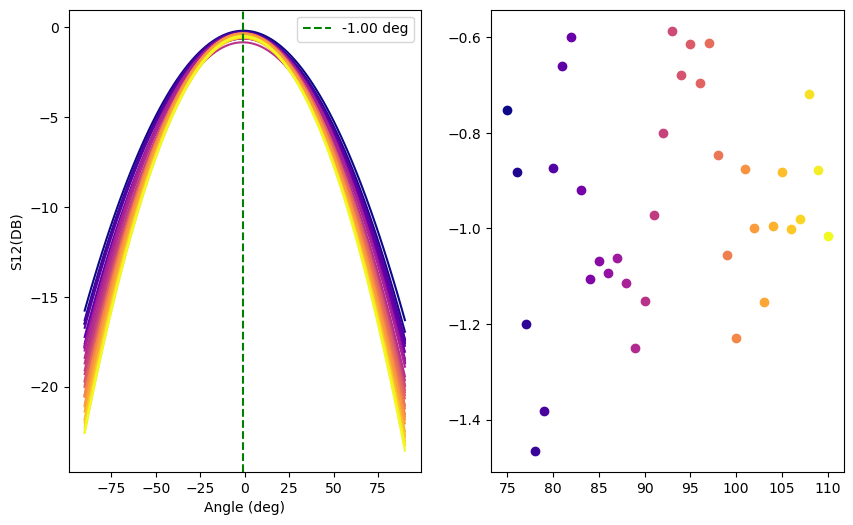

-0.9491709177277277


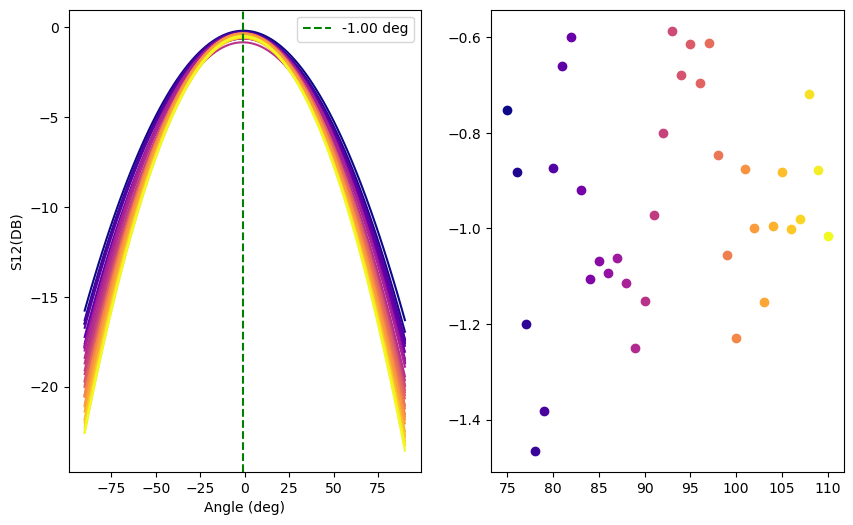

In [6]:
subcat = cat_tot[cat_tot["run"]>5]
plot_against_ang(subcat, key="S12(DB)")

subcat = cat_tot[cat_tot["run"]>5]
plot_against_ang(subcat, key="S12(DB)")

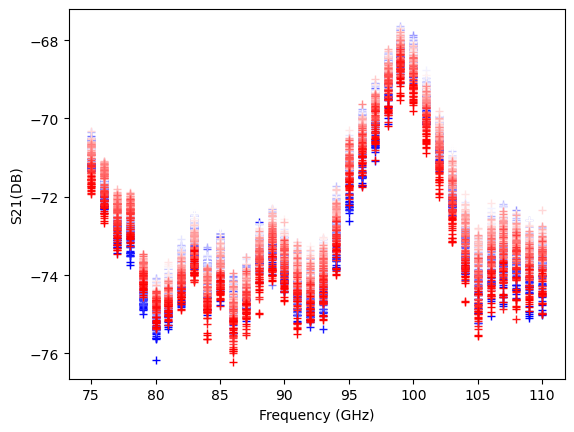

In [71]:
plot_against_freq(subcat, marker='+', ls="")

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
cat.sort_values(by="Ang(DEG)", inplace=True)

freq = 93
subcat = cat[cat["Freq(GHz)"] == freq]
axs[0].plot(subcat["Ang(DEG)"], (subcat["S21(DB)"] - subcat["S21(DB)"].max()), '+', color=cdict_freq[freq])
axs[1].plot(subcat["Ang(DEG)"], (subcat["S21(DEG)"] - subcat["S21(DEG)"].max()), '+', color=cdict_freq[freq])
axs[0].legend()
plt.show()

NameError: name 'cdict_freq' is not defined

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
cat.sort_values(by="Ang(DEG)", inplace=True)

# a, b, c = np.polyfit(cat["Ang(DEG)"], (cat["S12(DB)"] - cat["S12(DB)"].max()), deg=2)
# ang = cat["Ang(DEG)"].unique()
# fit = ang**2*a + ang*b

maxs = []

for freq in cat["Freq(GHz)"].unique():
    subcat = cat[cat["Freq(GHz)"] == freq]
    a, b, c = np.polyfit(subcat["Ang(DEG)"], (subcat["S12(DB)"] - subcat["S12(DB)"].max()), deg=2)
    ang = subcat["Ang(DEG)"].unique()
    fit = ang**2*a + ang*b
    maxs.append(ang[fit.argmax()])
    axs[0].plot(subcat["Ang(DEG)"], (subcat["S12(DB)"] - subcat["S12(DB)"].max()), '-', color=cdict_freq[freq])
    # axs[1].plot(subcat["Ang(DEG)"], (subcat["S21(DB)"] - subcat["S21(DB)"].max()), '-', color=cdict_freq[freq])
    #axs[1].plot(subcat["Ang(DEG)"], subcat["S12(DEG)"], 'o', color=cdict_freq[freq])

    #axs[0].plot(ang, fit, 'g-', lw=3)
axs[1].plot(cat["Freq(GHz)"].unique(), maxs, 'o')
axs[0].axvline(np.mean(maxs), color="g", ls="--", label=f"{ang[fit.argmax()]:.2f} deg")
axs[0].legend()
print(np.mean(maxs))
plt.show()

In [ ]:
c